<a href="https://colab.research.google.com/github/Arif2003-uem/Employee-Salary-Prediction/blob/main/IBM_Intership_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier


In [10]:
col_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

df = pd.read_csv('adult.csv', header=None, names=col_names,
                 na_values=' ?', skipinitialspace=True)
#remove rows containing null values
df.dropna(inplace=True)

In [11]:
encoders = {}
df_encoded = df.copy()

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])
    encoders[col] = le

In [12]:
X = df_encoded.drop('income', axis=1)
y = df_encoded['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [14]:
lr  = LogisticRegression(max_iter=500)
lr.fit(X_train_scaled, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test_scaled))

rf  = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_acc = accuracy_score(y_test, knn.predict(X_test_scaled))

gb  = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
gb_acc = accuracy_score(y_test, gb.predict(X_test))

In [16]:
models     = ['Logistic Regression', 'Random Forest', 'KNN', 'Gradient Boosting']
accuracies = [lr_acc, rf_acc, knn_acc, gb_acc]

print("\n========== MODEL ACCURACY COMPARISON ==========")
for m, a in zip(models, accuracies):
    print(f"  {m:<25} → {a*100:.2f}%")

best_idx   = accuracies.index(max(accuracies))
best_model = models[best_idx]
print(f"\n✅ Best Model: {best_model} ({max(accuracies)*100:.2f}%)")
print("================================================")



========== MODEL ACCURACY COMPARISON ==========
  Logistic Regression       → 78.85%
  Random Forest             → 84.80%
  KNN                       → 82.24%
  Gradient Boosting         → 86.11%

✅ Best Model: Gradient Boosting (86.11%)


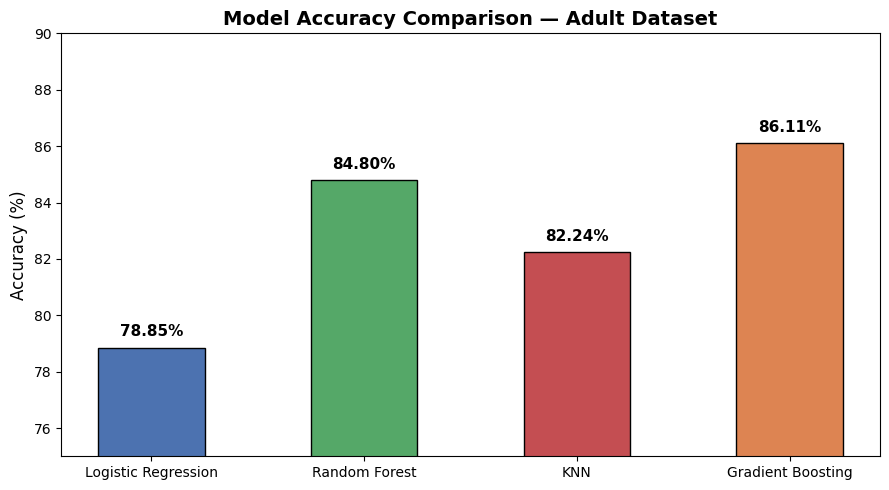

In [17]:
colors = ['#4C72B0', '#55A868', '#C44E52', '#DD8452']
plt.figure(figsize=(9, 5))
bars = plt.bar(models, [a * 100 for a in accuracies],
               color=colors, edgecolor='black', width=0.5)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f'{acc*100:.2f}%',
             ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.title('Model Accuracy Comparison — Adult Dataset', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(75, 90)
plt.tight_layout()
plt.show()

In [19]:
print("\n========== INCOME PREDICTOR ==========")
age = int(input("Enter Age: "))

# Fill all other columns with the most common value from training data
new_data = pd.DataFrame([X_train.median()])  # use median as default for everything
new_data['age'] = age                         # only override age

prediction = gb.predict(new_data)

print("\n========== PREDICTION RESULT ==========")
if prediction[0] == 1:
    print("💰 Predicted Income: MORE THAN $50K / year")
else:
    print("📉 Predicted Income: $50K OR LESS / year")
print("========================================")


========== INCOME PREDICTOR ==========
Enter Age: 45

========== PREDICTION RESULT ==========
📉 Predicted Income: $50K OR LESS / year
